In [1]:
from src.preprocessing import split_dataset, build_loader
from src.get_models import get_unet, get_attention_unet, get_unet_plus_plus, get_swin_unetr
from src.train_model import train_model
from src.evaluate_model import find_optim_threshold, groups_metrics_reports

In [2]:
# Разбиваем данные на подвыборки
train_df, val_df, test_df = split_dataset()

## Обучение на DWI и ADC

In [11]:
# Создаем лоадеры
train = build_loader(train_df, protocols_list=['dwi', 'adc'], augmentations=True, batch_size=4, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
val = build_loader(val_df, protocols_list=['dwi', 'adc'], augmentations=False, batch_size=1, shuffle=True)
test = build_loader(test_df, protocols_list=['dwi', 'adc'], augmentations=False, batch_size=1, shuffle=True)

### 3D U-Net

In [ ]:
unet, criterion, optimizer, scheduler = get_unet(in_channels=2)

Epoch 77 of 200
train loss: 	0.494484
val loss: 	0.436419
train dice: 			0.54
val dice: 			0.57


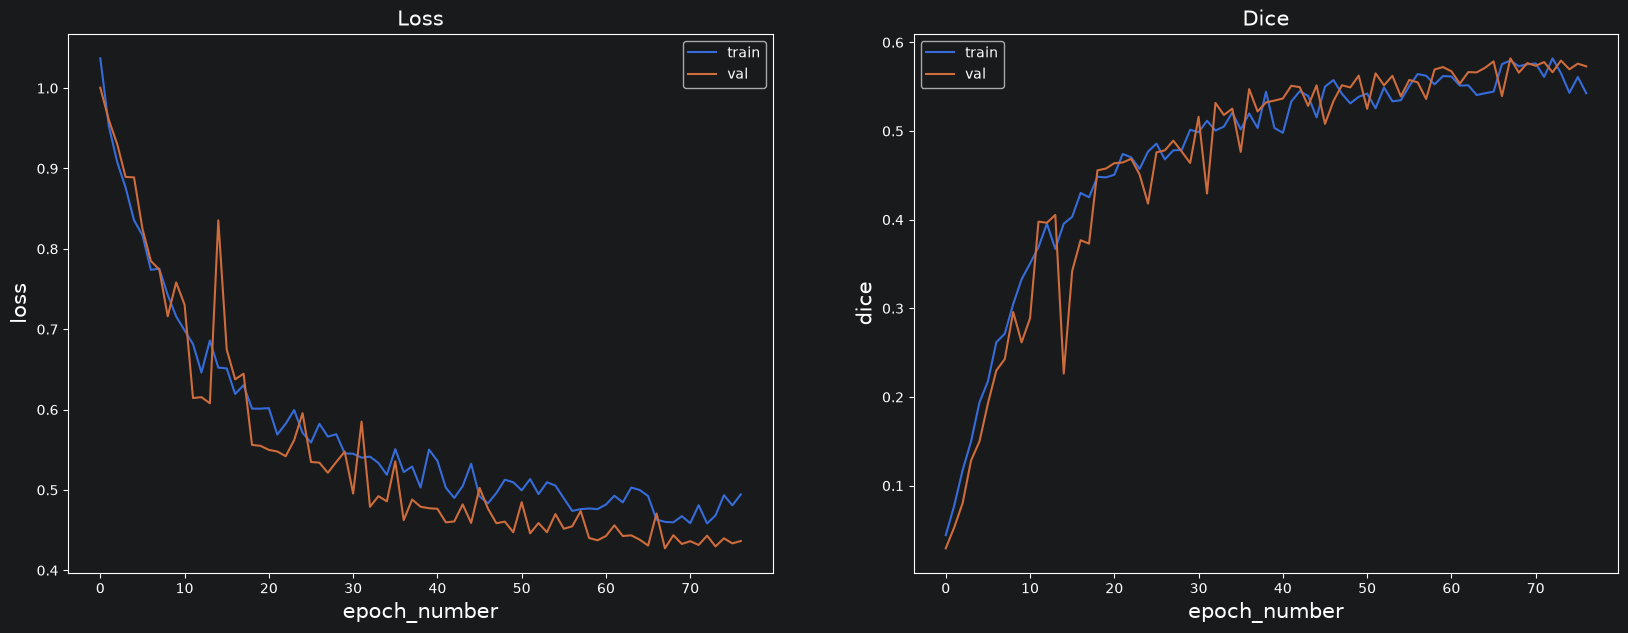

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\.venv\Lib\site-packages\monai\transforms\utils.py:682: UserWarning: Num foregrounds 0, Num backgrounds 3597440, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(


  0%|          | 0/26 [00:00<?, ?it/s]

In [5]:
train_model(
    unet, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_models', n_epochs=200, patience=10
)

5 минут на эпоху

In [4]:
unet = get_unet(in_channels=2, load_weights=True)

In [5]:
thresholds_metrics = find_optim_threshold(unet, test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd
8,0.5,0.884615,0.851852,0.867925,0.535502,0.412403,30.726926


In [5]:
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics = groups_metrics_reports(unet,  test_df, ['dwi', 'adc'], threshold=0.5)

In [6]:
all_lesion_metrics

,patient_group,patient_count,all_recall,all_precision,all_f1,all_dice,all_iou,all_hd
0,multiple_only_small_lesion,16,1.000000,0.428571,0.600000,0.793408,0.665956,1.138071
1,one_small_lesion,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,multiple_mixed_lesion,3,0.266667,0.160000,0.200000,0.211891,0.151127,4.637993
3,no_lesion,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,one_large_lesion,1,1.000000,0.100000,0.181818,0.473912,0.310541,14.317821


In [7]:
big_lesion_metrics

,patient_group,patient_count,big_recall,big_precision,big_f1,big_dice,big_iou,big_hd
2,multiple_mixed_lesion,3,1.0,1.0,1.0,0.827508,0.705769,2.000000
4,one_large_lesion,1,1.0,1.0,1.0,0.473912,0.310541,14.317821


In [8]:
small_lesion_metrics

,patient_group,patient_count,small_recall,small_precision,small_f1,small_dice,small_iou,small_hd
0,multiple_only_small_lesion,16,1.000000,0.428571,0.600000,0.793408,0.665956,1.138071
1,one_small_lesion,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,multiple_mixed_lesion,3,0.214286,0.125000,0.157895,0.167919,0.111509,4.931103


Исходя из метрик модели по группам пациентов и размерам очагов можно заключить:
1. Модель хорошо справляется с сегментацией множественных очагов для пациентов только с мелкими очагами, и крупных очагов для пациентов с очагами разных размеров, показывая для этих групп Dice, равный 0.79 и 0.83 соответственно. Однако на мелких очагах для пациентов с очагами разных размеров модель показывает Dice, равный 0.17, что крайне низко. Для пациентов с очагами разных размеров модель на крупных очагах сегментирует все истинные очаги и не генерирует ложные, а на мелких очагах сегментирует только 21% очагов и генерирует большое количество ложных. Для пациентов только с мелкими очагами модель обнаруживает все истинные очаги, но генерирует много случайных
2. Модель полностью пропускает снимки с одним небольшим очагом не производя их сегментацию, что, в совокупности с прошлым пунктом, говорит о том, что модель сильно смещена в сторону сегментации множественных очагов на изображении
3. Модель не сегментирует снимок без ишемии и посредственно сегментирует снимок с одним крупным очагом. Опираться на их метрики нельзя, так как в обеих группах только по 1 изображению

### 3D Attention U-Net

In [9]:
attention_unet, criterion, optimizer, scheduler = get_attention_unet(in_channels=2)

In [ ]:
train_model(
    attention_unet, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_models', n_epochs=200, patience=10
)

6 минут на эпоху

### 3D U-Net ++

In [8]:
unet_plus_plus, criterion, optimizer, scheduler = get_unet_plus_plus(in_channels=2)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [ ]:
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_models', n_epochs=200, patience=10
)

18 минут на эпоху

### Swin UNETR

In [10]:
swin_unetr, criterion, optimizer, scheduler = get_swin_unetr(in_channels=2)

In [ ]:
train_model(
    swin_unetr, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_models', n_epochs=200, patience=10
)

10 минут на эпоху

## Обучение на DWI, ADC и Flair

In [12]:
# Создаем лоадеры
train = build_loader(train_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=True, batch_size=4, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
val = build_loader(val_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)
test = build_loader(test_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)

### 3D U-Net

In [13]:
unet, criterion, optimizer, scheduler = get_unet(in_channels=3)

In [ ]:
train_model(
    unet, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_flair_models', n_epochs=200, patience=10
)

10 минут на эпоху

### 3D Attention U-Net

In [15]:
attention_unet, criterion, optimizer, scheduler = get_attention_unet(in_channels=3)

In [ ]:
train_model(
    attention_unet, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_flair_models', n_epochs=200, patience=10
)

10 минут на эпоху

### 3D U-Net ++

In [17]:
unet_plus_plus, criterion, optimizer, scheduler = get_unet_plus_plus(in_channels=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [ ]:
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_flair_models', n_epochs=200, patience=10
)

23 минут на эпоху

### Swin UNETR

In [19]:
swin_unetr, criterion, optimizer, scheduler = get_swin_unetr(in_channels=3)

Epoch 1 of 200
train loss: 	0.991691
val loss: 	0.994728
train dice: 			nan
val dice: 			0.03


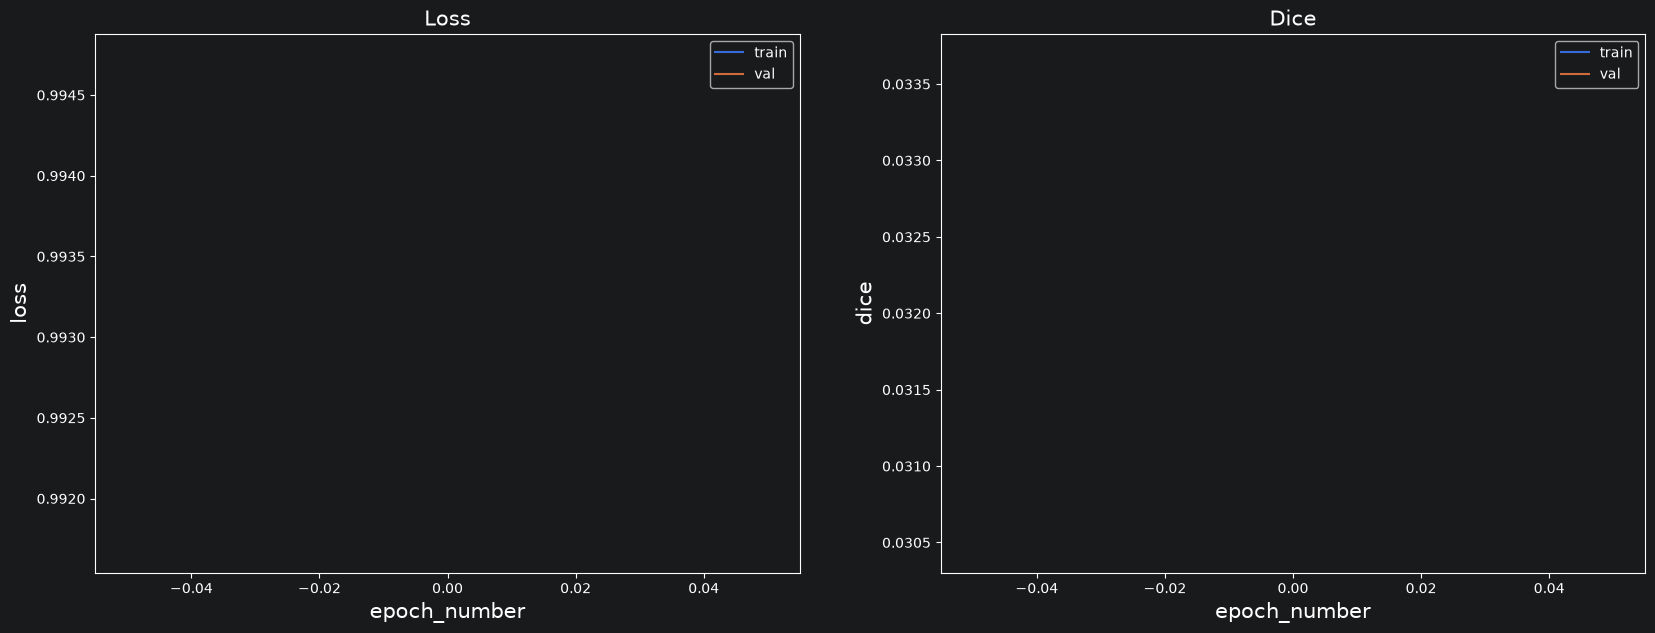

In [20]:
train_model(
    swin_unetr, criterion, optimizer, scheduler, train, val,
    weights_dir_name='dwi_adc_flair_models', n_epochs=200, patience=10
)

14 минут на эпоху